In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from node2vec import Node2Vec

c:\Users\alice\Downloads\Kaggle_MLNS\Predicting-Missing-Link-in-an-Actor-Co-Occurrence-Network\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
train = pd.read_csv("data/train.txt", sep=" ", header=None)
train.head()

,0,1,2
0,939,3809,1
1,2442,5784,1
2,179,3809,1
3,857,2280,1
4,1358,5722,1


In [55]:
train.columns = ["u", "v", "label"]
train.head()

,u,v,label
0,939,3809,1
1,2442,5784,1
2,179,3809,1
3,857,2280,1
4,1358,5722,1


In [56]:
G = nx.Graph()
edges = train[train["label"] == 1][["u", "v"]].values
G.add_edges_from(edges)

In [57]:
test = pd.read_csv("data/test.txt", sep=" ", header=None)
test.columns = ["u", "v"]
test.head()

,u,v
0,3425,4524
1,1620,2617
2,4832,6317
3,4984,7298
4,385,5481


In [58]:
node_info = pd.read_csv("data/node_information.csv", header=None)
node_info.head()

,0,1,2,3,4,5,6,7,8,9,...,923,924,925,926,927,928,929,930,931,932
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
node_info = node_info.rename(columns={0: "node"})
node_info.head()

,node,1,2,3,4,5,6,7,8,9,...,923,924,925,926,927,928,929,930,931,932
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
node_features = {
    int(row["node"]): row.drop("node").values
    for _, row in node_info.iterrows()
}

In [61]:
for u, v in G.edges():
    x_u = node_features[u]
    x_v = node_features[v]

    sim = np.dot(x_u, x_v)
    G[u][v]['weight'] = 1 + 0.1 * sim

In [62]:
weights = [G[u][v]['weight'] for u, v in G.edges()]
print(min(weights), max(weights))

1.0 2.6


In [63]:
node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=20,
    num_walks=20,
    workers=1,
    p=1,
    q=0.5
    #weight_key='weight' pour poids des arêtes = infos issues des features textuelles 
)

model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=64
)

Generating walks (CPU: 1): 100%|██████████| 20/20 [00:09<00:00,  2.14it/s]


In [64]:
embeddings = model.wv

In [65]:
train_samples = train[["u", "v"]].values
train_labels = train["label"].values

test_samples = test[["u", "v"]].values

In [66]:
def edge_features(u, v):
    z_u = embeddings[str(u)]
    z_v = embeddings[str(v)]
    
    return np.abs(z_u - z_v)

In [67]:
#on peut tester plein de configurations différentes, pour le moment toutes sont nulles :( 

def edge_features(u, v):
    z_u = embeddings[str(u)]
    z_v = embeddings[str(v)]

    #diff = np.abs(z_u - z_v) 
    dist = np.linalg.norm(z_u - z_v)
    dot = np.dot(z_u, z_v)

    #return np.concatenate([diff, [dist], [dot]])
    return np.concatenate([[dist], [dot]])

In [68]:
X_train = [edge_features(u, v) for u, v in train_samples]
y_train = train_labels

In [69]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [70]:
def score(u, v):
    z_u = embeddings[str(u)]
    z_v = embeddings[str(v)]
    return np.dot(z_u, z_v)

pos_scores = [score(u, v) for u, v, y in train.values if y == 1]
neg_scores = [score(u, v) for u, v, y in train.values if y == 0]

print("pos mean:", np.mean(pos_scores))
print("neg mean:", np.mean(neg_scores))

pos mean: 12.052998
neg mean: 4.402481


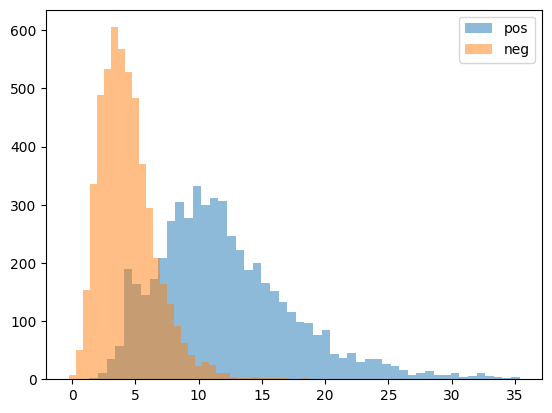

In [71]:
import matplotlib.pyplot as plt

plt.hist(pos_scores, bins=50, alpha=0.5, label="pos")
plt.hist(neg_scores, bins=50, alpha=0.5, label="neg")
plt.legend()

In [ ]:
#donc arrive en partie à distinguer 0 et 1 

In [76]:
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

proba = clf.predict_proba(X_train)[:, 1]
pred = clf.predict(X_train)

print("AUC:", roc_auc_score(y_train, proba))
print("Accuracy:", accuracy_score(y_train, pred))
print(confusion_matrix(y_train, pred))

AUC: 0.9970367268250855
Accuracy: 0.9923780487804879
[[5179   69]
 [  11 5237]]


In [79]:
X_test = [edge_features(u, v) for u, v in test_samples]

y_test = clf.predict(X_test)

In [80]:
submission = pd.DataFrame({
    "ID": range(len(y_test)),
    "Predicted": y_test
})

submission.to_csv("submissions/submission_overfit.csv", index=False)

In [ ]:
#overfit le train, et ne prédit pratiquement que des 0, alors que dans le TP on était plutôt autour de 
#0.65-0.8, je n'arrive pas à comprendre pourquoi 